In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [2]:
# Example: X contains sensor inputs, y contains target values
import pandas as pd

# Load CSV
data = pd.read_csv("fbg_sensor_strain_temperature_data.csv")   # replace with actual filename

# Suppose your columns are like:
# FBG1, FBG2, FBG3, strain, temp

X = data[["FBG1", "FBG2", "FBG3"]].values
y_strain = data["Strain"].values
y_temp = data["Temperature"].values

# For combined output (strain + temp)
y = y_strain + y_temp

# Replace with your actual dataset
# X = np.load("X.npy")   # shape: (n_samples, 3)  [FBG1, FBG2, FBG3]
# y_strain = np.load("y_strain.npy")
# y_temp = np.load("y_temp.npy")

# If you want to train on strain+temp combined (sum)
y = y_strain + y_temp   # or np.column_stack([y_strain, y_temp]) if you want multi-output

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [3]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # Single output for strain+temp
])

model.compile(optimizer='adam', loss='mse')


C:\Users\saanv\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)


Epoch 1/100


 1/40 ━━━━━━━━━━━━━━━━━━━━ 35s 905ms/step - loss: 101.6092

35/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 88.6626    

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 78.1698 - val_loss: 54.4100


Epoch 2/100


...

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2769 - val_loss: 0.0252


Epoch 100/100


 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.2991

38/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2737 

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2522 - val_loss: 0.0328


In [5]:
y_pred = model.predict(X_test).flatten()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("ANN MSE:", mse)
print("ANN R²:", r2)

# Residuals
residuals_ann = y_test - y_pred


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


ANN MSE:

 0.04767932520472714
ANN R²: 0.9956452736117284


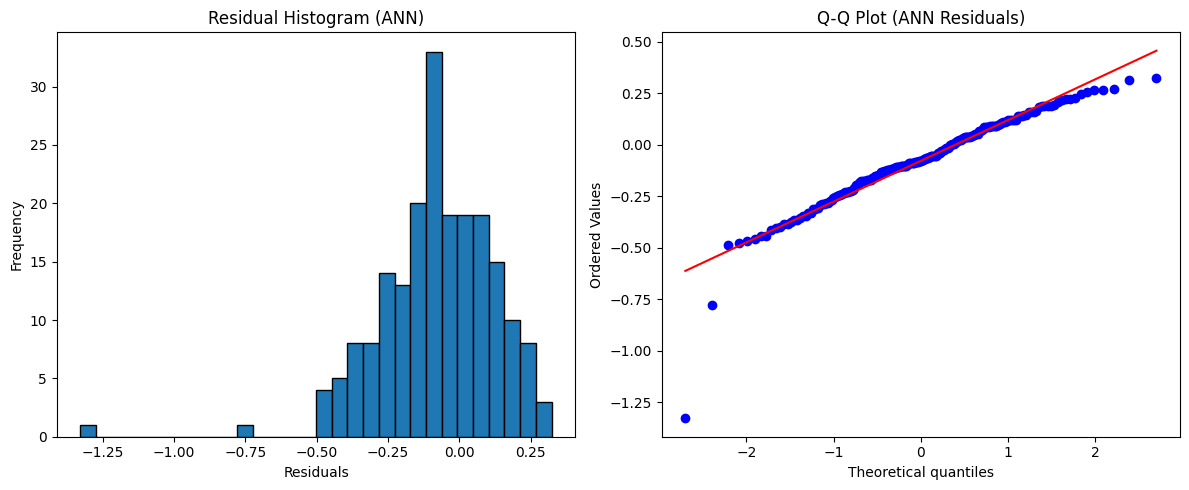

In [6]:
import scipy.stats as stats

plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
plt.hist(residuals_ann, bins=30, edgecolor='black')
plt.title("Residual Histogram (ANN)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

# Q-Q plot
plt.subplot(1,2,2)
stats.probplot(residuals_ann, dist="norm", plot=plt)
plt.title("Q-Q Plot (ANN Residuals)")

plt.tight_layout()
plt.show()


C:\Users\saanv\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


MSE: 0.0253
MAE: 0.1291
R² : 0.9977


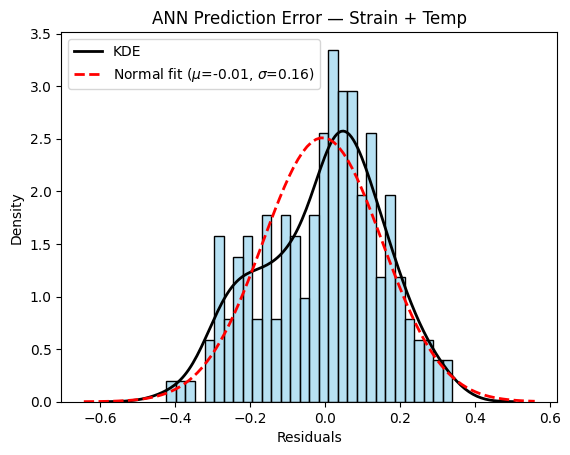

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# # ----------------------------
# # Load your data
# # ----------------------------
# X = np.load("X.npy")   # Features
# y = np.load("y.npy")   # Targets

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------------------------
# Build ANN model
# ----------------------------
model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)  # regression output
])

model.compile(optimizer="adam", loss="mse")

# Train
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

# ----------------------------
# Predictions and residuals
# ----------------------------
y_pred = model.predict(X_test).flatten()
residuals = y_test - y_pred


# Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² : {r2:.4f}")

# ----------------------------
# Plot residual histogram + KDE + Normal fit
# ----------------------------
mu, sigma = norm.fit(residuals)

sns.histplot(residuals, bins=30, kde=False, stat="density", color="skyblue", alpha=0.6)
sns.kdeplot(residuals, color="black", linewidth=2, label="KDE")

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, "r--", linewidth=2, label=f"Normal fit ($\\mu$={mu:.2f}, $\\sigma$={sigma:.2f})")

plt.xlabel("Residuals")
plt.ylabel("Density")
plt.title("ANN Prediction Error — Strain + Temp")
plt.legend()
plt.savefig("ANN_S+T.png", dpi=300, bbox_inches='tight')
plt.show()


In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

# ----------------------------
# Load your data
# ----------------------------
data = pd.read_csv("fbg_sensor_strain_temperature_data.csv")

# Features: FBG1, FBG2, FBG3
X = data[["FBG1", "FBG2", "FBG3"]].values

# Targets: strain, temp
y_strain = data["Strain"].values
y_temp = data["Temperature"].values

# Combine into 2D target: (n_samples, 2)
y = np.column_stack((y_strain, y_temp))

# ----------------------------
# Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features (important for ANN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ----------------------------
# ANN Model
# ----------------------------
model = keras.Sequential([
    layers.Input(shape=(3,)),          # 3 inputs: FBG1, FBG2, FBG3
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(2)  # 2 outputs: strain & temperature
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(X_train, y_train, epochs=100, batch_size=16,
                    validation_data=(X_test, y_test), verbose=1)

# ----------------------------
# Evaluate
# ----------------------------
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")

# ----------------------------
# Predictions
# ----------------------------
y_pred = model.predict(X_test)

# Example: Compare first 5 true vs predicted
print("True:", y_test[:5])
print("Pred:", y_pred[:5])


Epoch 1/100


 1/50 ━━━━━━━━━━━━━━━━━━━━ 38s 792ms/step - loss: 22.7170 - mae: 4.6145

34/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.5328 - mae: 4.0718   

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 15.1584 - mae: 3.5309 - val_loss: 6.7987 - val_mae: 2.2680


Epoch 2/100


...

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0102 - mae: 0.0803 - val_loss: 0.0126 - val_mae: 0.0908


Test Loss: 0.0126, Test MAE: 0.0908


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


True: [[5.18198496 4.17947401]
 [6.59978209 5.11159813]
 [3.33034181 2.683551  ]
 [5.06170358 4.12077103]
 [3.77946879 3.14886436]]
Pred: [[5.12899   4.191317 ]
 [6.4831944 5.0953555]
 [3.5165195 2.8231096]
 [5.0250363 4.116593 ]
 [3.8991926 3.1889894]]


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


Strain -> MSE: 0.0131, R²: 0.9962
Temp   -> MSE: 0.0121, R²: 0.9944


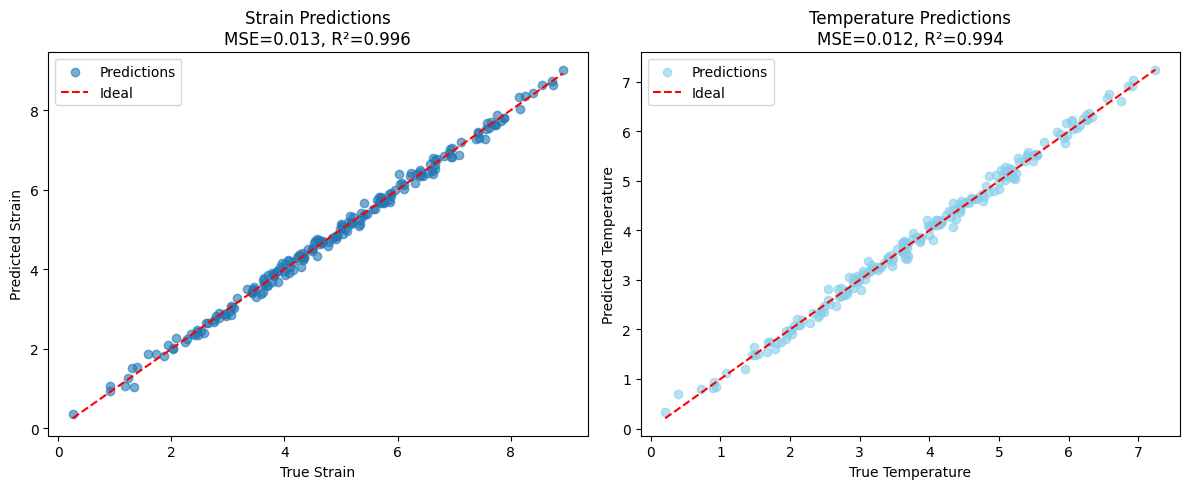

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
y_pred = model.predict(X_test)

strain_true = y_test[:, 0]
strain_pred = y_pred[:, 0]

temp_true = y_test[:, 1]
temp_pred = y_pred[:, 1]

# --- Metrics ---
strain_mse = mean_squared_error(strain_true, strain_pred)
strain_r2 = r2_score(strain_true, strain_pred)

temp_mse = mean_squared_error(temp_true, temp_pred)
temp_r2 = r2_score(temp_true, temp_pred)

print(f"Strain -> MSE: {strain_mse:.4f}, R²: {strain_r2:.4f}")
print(f"Temp   -> MSE: {temp_mse:.4f}, R²: {temp_r2:.4f}")

# --- Plot parity plots ---
plt.figure(figsize=(12,5))

# Strain
plt.subplot(1,2,1)
plt.scatter(strain_true, strain_pred, alpha=0.6, label="Predictions")
plt.plot([strain_true.min(), strain_true.max()],
         [strain_true.min(), strain_true.max()], 'r--', label="Ideal")
plt.xlabel("True Strain")
plt.ylabel("Predicted Strain")
plt.title(f"Strain Predictions\nMSE={strain_mse:.3f}, R²={strain_r2:.3f}")
plt.legend()

# Temp
plt.subplot(1,2,2)
plt.scatter(temp_true, temp_pred, alpha=0.6, color="skyblue", label="Predictions")
plt.plot([temp_true.min(), temp_true.max()],
         [temp_true.min(), temp_true.max()], 'r--', label="Ideal")
plt.xlabel("True Temperature")
plt.ylabel("Predicted Temperature")
plt.title(f"Temperature Predictions\nMSE={temp_mse:.3f}, R²={temp_r2:.3f}")
plt.legend()
plt.savefig("ANN_scatter.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


Strain -> MSE: 0.0131, R²: 0.9962
Temp   -> MSE: 0.0121, R²: 0.9944


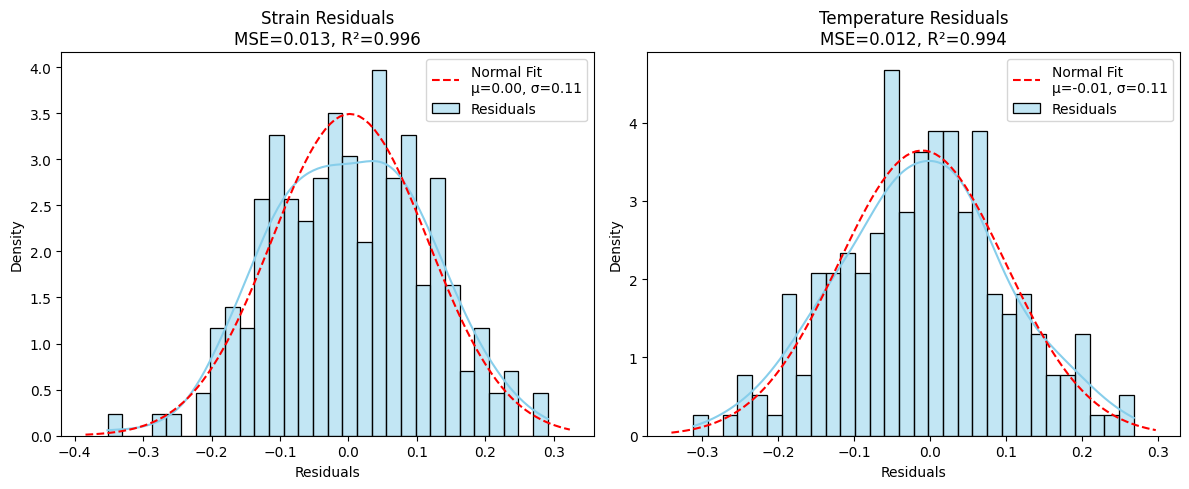

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import norm

# Predictions
y_pred = model.predict(X_test)

strain_true = y_test[:, 0]
strain_pred = y_pred[:, 0]
strain_resid = strain_true - strain_pred

temp_true = y_test[:, 1]
temp_pred = y_pred[:, 1]
temp_resid = temp_true - temp_pred

# --- Metrics ---
strain_mse = mean_squared_error(strain_true, strain_pred)
strain_r2 = r2_score(strain_true, strain_pred)

temp_mse = mean_squared_error(temp_true, temp_pred)
temp_r2 = r2_score(temp_true, temp_pred)

print(f"Strain -> MSE: {strain_mse:.4f}, R²: {strain_r2:.4f}")
print(f"Temp   -> MSE: {temp_mse:.4f}, R²: {temp_r2:.4f}")

# --- Residual Histograms with KDE + Normal ---
plt.figure(figsize=(12,5))

# Strain residuals
plt.subplot(1,2,1)
sns.histplot(strain_resid, kde=True, stat="density", bins=30, color="skyblue", label="Residuals")
mu, std = norm.fit(strain_resid)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r--', label=f"Normal Fit\nμ={mu:.2f}, σ={std:.2f}")
plt.title(f"Strain Residuals\nMSE={strain_mse:.3f}, R²={strain_r2:.3f}")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.legend()

# Temp residuals
plt.subplot(1,2,2)
sns.histplot(temp_resid, kde=True, stat="density", bins=30, color="skyblue", label="Residuals")
mu, std = norm.fit(temp_resid)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r--', label=f"Normal Fit\nμ={mu:.2f}, σ={std:.2f}")
plt.title(f"Temperature Residuals\nMSE={temp_mse:.3f}, R²={temp_r2:.3f}")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.legend()
plt.savefig("ANN_SEPERATE.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()
